# Modular Affine + TPS Registration Demo

This notebook demonstrates a **modular architecture** for image registration:

1. **Correspondence Generation** (separate module): Takes two images → returns correspondence points
2. **Registration/Warping** (separate module): Takes correspondences → returns warped image

This separation allows you to easily swap different correspondence methods (LightGlue, SIFT, ORB, AKAZE) without changing the registration logic.


In [ ]:
# Install required packages
# !pip install scipy scikit-image
# !pip install -r requirements.txt


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)


## Configuration

Set your image paths or DSA item IDs


In [40]:
# Use local image files (no DSA required)
USE_DSA = False  # Set to True to use DSA item IDs instead

if USE_DSA:
    # Option 1: Use DSA item IDs
    FIXED_IMAGE_ID = "695d9f428c871f3a02969d62"  # HE (fixed) image
    MOVING_IMAGE_ID = "695d9f428c871f3a02969d60"  # Moving image (e.g., IHC stain)
    
    print(f"Using DSA images:")
    print(f"  Fixed (HE): {FIXED_IMAGE_ID}")
    print(f"  Moving: {MOVING_IMAGE_ID}")
else:
    # Option 2: Use local image files
    FIXED_IMAGE_PATH = "/home/candano/DSA-Tissue-Reg/temp4/thumbnail_695e74748c871f3a0296c315.png"
    MOVING_IMAGE_PATH = "/home/candano/DSA-Tissue-Reg/temp4/thumbnail_695e74748c871f3a0296c317.png"
    
    print(f"Using local images:")
    print(f"  Fixed: {FIXED_IMAGE_PATH}")
    print(f"  Moving: {MOVING_IMAGE_PATH}")


Using local images:
  Fixed: /home/candano/DSA-Tissue-Reg/temp4/thumbnail_695e74748c871f3a0296c315.png
  Moving: /home/candano/DSA-Tissue-Reg/temp4/thumbnail_695e74748c871f3a0296c317.png


## Load Images


Loading images from local files...
Fixed image shape: (768, 951, 3)
Moving image shape: (768, 906, 3)


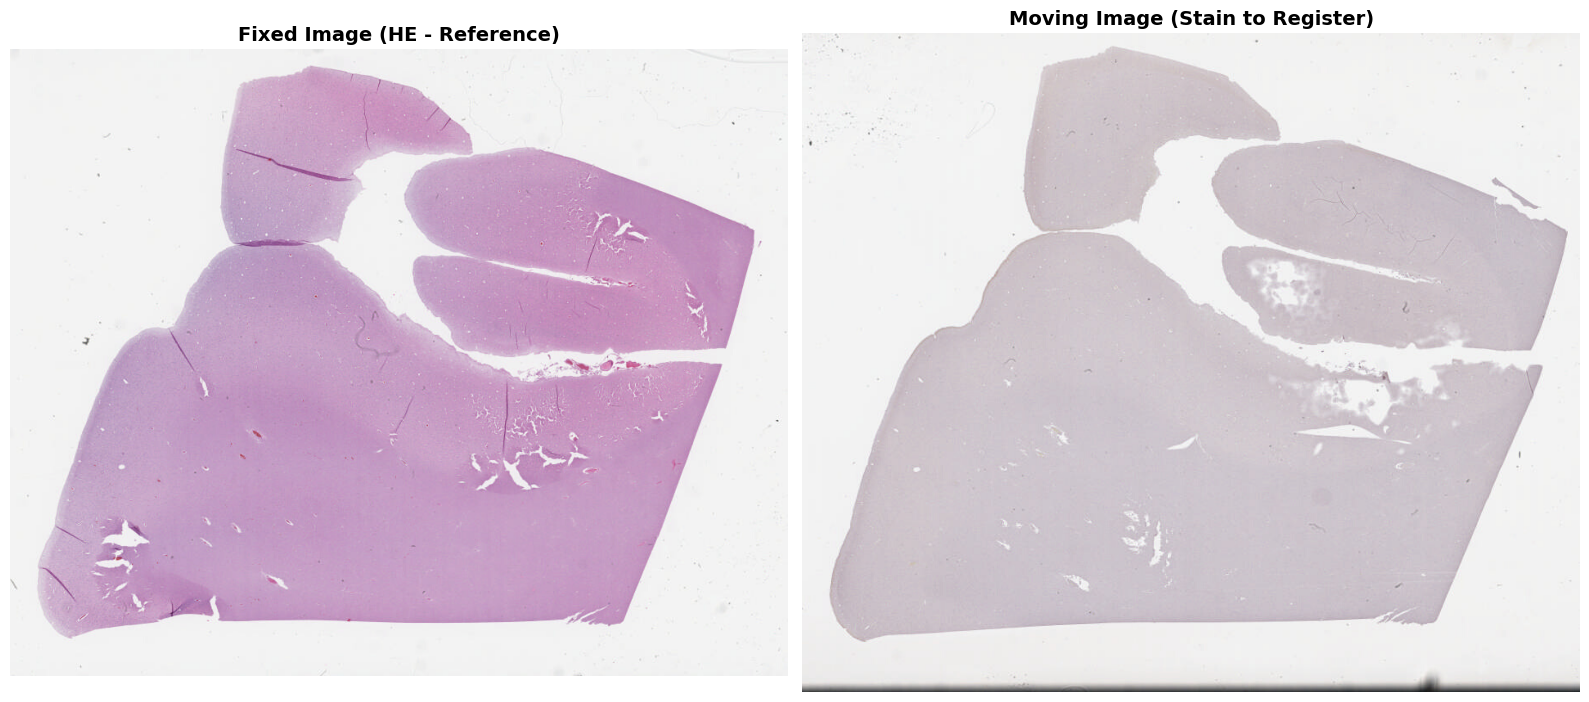

In [41]:
def load_images_from_files(fixed_path: str, moving_path: str):
    """Load images from local files"""
    print("Loading images from local files...")
    fixed_img = np.array(Image.open(fixed_path).convert('RGB'))
    moving_img = np.array(Image.open(moving_path).convert('RGB'))
    
    print(f"Fixed image shape: {fixed_img.shape}")
    print(f"Moving image shape: {moving_img.shape}")
    
    return fixed_img, moving_img

# Load images
if USE_DSA:
    # Add DSA loading code here if needed
    raise NotImplementedError("DSA loading not implemented in this demo")
else:
    fixed_img, moving_img = load_images_from_files(FIXED_IMAGE_PATH, MOVING_IMAGE_PATH)

# Display input images
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(fixed_img)
axes[0].set_title('Fixed Image (HE - Reference)', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(moving_img)
axes[1].set_title('Moving Image (Stain to Register)', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Modular Correspondence Generation

This section defines correspondence generation functions that are **separate** from the warping/registration logic.
Different methods (LightGlue, SIFT, ORB, AKAZE) can be used interchangeably.


## Architecture Overview

The registration pipeline is now **modular** with two separate components:

1. **Correspondence Generation** (cells above):
   - Takes two images → returns correspondence points
   - Multiple methods available: LightGlue, SIFT, OccRB, AKAZE
   - This is the middle function that generates the dictionary of correspondence points
   - **Independent** of the registration/warping logic

2. **Registration/Warping** (cells above):
   - Takes correspondences → returns warped image
   - Standard Affine + TPS registration
   - **Independent** of how correspondences were generated

**Key Benefit**: You can swap correspondence methods without changing the registration logic!


## Modular Correspondence Generation

This section defines correspondence generation functions that are **separate** from the warping/registration logic.
Different methods (LightGlue, SIFT, etc.) can be used interchangeably.


In [ ]:
def generate_correspondences(img1, img2, method="lightglue", **kwargs):
    """
    Generate correspondence points between two images.
    
    This is the modular middle function that takes image1 and image2
    and generates a dictionary of correspondence points.
    
    Args:
        img1: numpy array (H, W, 3) - fixed/reference image (RGB)
        img2: numpy array (H, W, 3) - moving image (RGB)
        method: str - method to use ('lightglue', 'sift', 'orb', 'akaze')
        **kwargs: method-specific parameters
    
    Returns:
        dict with keys:
            - 'points1': np.array (N, 2) - points in img1
            - 'points2': np.array (N, 2) - points in img2
            - 'confidence': np.array (N,) - optional match confidence scores
            - 'method': str - method used
            - 'num_matches': int - number of correspondences
    """
    if method == "lightglue":
        # Filter kwargs for LightGlue: all tunable parameters
        lightglue_kwargs = {k: v for k, v in kwargs.items() 
                           if k in ['extractor_type', 'max_keypoints', 'confidence_threshold', 'device',
                                   'detection_threshold', 'nms_window_size',
                                   'depth_confidence', 'width_confidence', 'filter_threshold',
                                   'n_layers', 'mask1', 'mask2']}
        return generate_correspondences_lightglue(img1, img2, **lightglue_kwargs)
    elif method == "sift":
        # Filter kwargs for SIFT: nfeatures, ratio_thresh, cross_check
        sift_kwargs = {k: v for k, v in kwargs.items() 
                      if k in ['nfeatures', 'ratio_thresh', 'cross_check']}
        return generate_correspondences_sift(img1, img2, **sift_kwargs)
    elif method == "orb":
        # Filter kwargs for ORB: nfeatures, score_type
        orb_kwargs = {k: v for k, v in kwargs.items() 
                     if k in ['nfeatures', 'score_type']}
        return generate_correspondences_orb(img1, img2, **orb_kwargs)
    elif method == "akaze":
        # Filter kwargs for AKAZE: threshold
        akaze_kwargs = {k: v for k, v in kwargs.items() 
                       if k in ['threshold']}
        return generate_correspondences_akaze(img1, img2, **akaze_kwargs)
    else:
        raise ValueError(f"Unknown method: {method}. Choose from: lightglue, sift, orb, akaze")


def generate_correspondences_lightglue(img1, img2, extractor_type="superpoint", max_keypoints=2048, #2048,4096
                                      confidence_threshold=0.1, device=None, #0.03
                                      detection_threshold=None, nms_window_size=None,
                                      depth_confidence=0.9, width_confidence=0.99, filter_threshold=0.1,
                                      n_layers=9, mask1=None, mask2=None):
    """
    Generate correspondences using LightGlue (learning-based feature matcher).
    
    Args:
        img1, img2: numpy arrays (H, W, 3) RGB images
        extractor_type: 'superpoint', 'disk', 'aliked', 'sift'
        max_keypoints: maximum number of keypoints to extract (default: 2048)
        confidence_threshold: minimum match confidence for post-filtering (0-1, default: 0.0 = no filtering)
        device: 'cuda' or 'cpu' (None = auto)
        
        # Extractor parameters (for keypoint detection):
        detection_threshold: minimum score for keypoint detection (lower = more keypoints, default: extractor default)
        nms_window_size: window size for non-maximum suppression (default: extractor default)
        
        # Matcher parameters (for LightGlue matching):
        depth_confidence: early stopping confidence (0-1, default: 0.9, higher = faster but may miss matches)
        width_confidence: point pruning confidence (0-1, default: 0.99, higher = more aggressive pruning)
        filter_threshold: filter threshold for matches (0-1, default: 0.1, lower = stricter filtering)
        n_layers: number of attention layers/iterations (default: 9, more = better quality but slower)
        
        # Mask parameters (for focusing feature extraction):
        mask1, mask2: optional binary masks (H, W) or (H, W, 1) numpy arrays, where 1=valid region, 0=ignore
                     If provided, features will only be extracted in masked regions (1s)
                     Masks should match the image dimensions
    
    Returns:
        dict with correspondence points
    """
    try:
        from lightglue import LightGlue, SuperPoint, DISK, ALIKED, SIFT
        from lightglue.utils import rbd
        import torch
        from torchvision.transforms import ToTensor
    except ImportError:
        raise ImportError("LightGlue is required. Install with: pip install lightglue")
    
    # Ensure RGB format
    if isinstance(img1, np.ndarray):
        if img1.dtype != np.uint8:
            img1 = (img1 * 255).astype(np.uint8) if img1.max() <= 1.0 else img1.astype(np.uint8)
        if len(img1.shape) == 2:
            img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
        elif img1.shape[2] == 4:
            img1 = cv2.cvtColor(img1, cv2.COLOR_RGBA2RGB)
    else:
        img1 = np.array(img1.convert('RGB'))
    
    if isinstance(img2, np.ndarray):
        if img2.dtype != np.uint8:
            img2 = (img2 * 255).astype(np.uint8) if img2.max() <= 1.0 else img2.astype(np.uint8)
        if len(img2.shape) == 2:
            img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
        elif img2.shape[2] == 4:
            img2 = cv2.cvtColor(img2, cv2.COLOR_RGBA2RGB)
    else:
        img2 = np.array(img2.convert('RGB'))
    
    # Apply masks if provided (masks should be binary: 1=valid, 0=ignore)
    if mask1 is not None:
        mask1 = np.array(mask1)
        if len(mask1.shape) == 3:
            mask1 = mask1[:, :, 0] if mask1.shape[2] == 1 else mask1[:, :, 0]
        # Normalize mask to 0-1 range if needed
        if mask1.max() > 1:
            mask1 = (mask1 > 127).astype(np.float32)
        else:
            mask1 = mask1.astype(np.float32)
        # Check dimensions match
        if mask1.shape[:2] != img1.shape[:2]:
            raise ValueError(f"mask1 shape {mask1.shape[:2]} doesn't match img1 shape {img1.shape[:2]}")
        # Apply mask: set masked-out regions to black
        img1 = (img1 * mask1[:, :, np.newaxis]).astype(np.uint8)
    
    if mask2 is not None:
        mask2 = np.array(mask2)
        if len(mask2.shape) == 3:
            mask2 = mask2[:, :, 0] if mask2.shape[2] == 1 else mask2[:, :, 0]
        # Normalize mask to 0-1 range if needed
        if mask2.max() > 1:
            mask2 = (mask2 > 127).astype(np.float32)
        else:
            mask2 = mask2.astype(np.float32)
        # Check dimensions match
        if mask2.shape[:2] != img2.shape[:2]:
            raise ValueError(f"mask2 shape {mask2.shape[:2]} doesn't match img2 shape {img2.shape[:2]}")
        # Apply mask: set masked-out regions to black
        img2 = (img2 * mask2[:, :, np.newaxis]).astype(np.uint8)
    
    # Convert to torch tensors
    to_tensor = ToTensor()
    tensor1 = to_tensor(img1).unsqueeze(0)  # [1, 3, H, W]
    tensor2 = to_tensor(img2).unsqueeze(0)
    
    # Initialize extractor and matcher
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    extractor_map = {
        "superpoint": SuperPoint,
        "disk": DISK,
        "aliked": ALIKED,
        "sift": SIFT
    }
    
    if extractor_type not in extractor_map:
        raise ValueError(f"Unknown extractor: {extractor_type}")
    
    # Build extractor with optional parameters
    extractor_kwargs = {"max_num_keypoints": max_keypoints}
    if detection_threshold is not None:
        extractor_kwargs["detection_threshold"] = detection_threshold
    if nms_window_size is not None:
        extractor_kwargs["nms_window_size"] = nms_window_size
    
    extractor = extractor_map[extractor_type](**extractor_kwargs).eval().to(device)
    
    # Build matcher with optional parameters
    matcher_kwargs = {"features": extractor_type}
    if n_layers is not None:
        matcher_kwargs["n_layers"] = n_layers
    if depth_confidence is not None:
        matcher_kwargs["depth_confidence"] = depth_confidence
    if width_confidence is not None:
        matcher_kwargs["width_confidence"] = width_confidence
    if filter_threshold is not None:
        matcher_kwargs["filter_threshold"] = filter_threshold
    
    matcher = LightGlue(**matcher_kwargs).eval().to(device)
    
    # Extract features and match
    with torch.no_grad():
        feats1 = extractor.extract(tensor1.to(device))
        feats2 = extractor.extract(tensor2.to(device))
        matches = matcher({"image0": feats1, "image1": feats2})
        feats1, feats2, matches = [rbd(x) for x in [feats1, feats2, matches]]
    
    # Get matched keypoints
    kpts1 = feats1["keypoints"].cpu().numpy()  # Points in img1
    kpts2 = feats2["keypoints"].cpu().numpy()  # Points in img2
    match_indices = matches["matches"].cpu().numpy()  # [N, 2] with indices
    
    # Filter valid matches
    valid = match_indices[:, 0] >= 0
    match_idx1 = match_indices[valid, 0]
    match_idx2 = match_indices[valid, 1]
    
    points1 = kpts1[match_idx1]  # Corresponding points in img1
    points2 = kpts2[match_idx2]  # Corresponding points in img2
    
    # Get confidence scores if available
    confidence = None
    if "matching_scores" in matches:
        confidence = matches["matching_scores"].cpu().numpy()[valid]
        # Filter by confidence threshold
        if confidence_threshold > 0:
            valid_conf = confidence >= confidence_threshold
            points1 = points1[valid_conf]
            points2 = points2[valid_conf]
            confidence = confidence[valid_conf]
    
    return {
        "points1": points1,
        "points2": points2,
        "confidence": confidence,
        "method": "lightglue",
        "num_matches": len(points1),
        "extractor_type": extractor_type
    }


def generate_correspondences_sift(img1, img2, nfeatures=2000, ratio_thresh=0.75, cross_check=True):
    """
    Generate correspondences using SIFT (Scale-Invariant Feature Transform).
    
    Args:
        img1, img2: numpy arrays (H, W, 3) RGB images
        nfeatures: maximum number of features to detect
        ratio_thresh: Lowe's ratio test threshold (lower = more strict)
        cross_check: whether to perform cross-validation of matches
    
    Returns:
        dict with correspondence points
    """
    # Convert to grayscale
    if len(img1.shape) == 3:
        gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    else:
        gray1 = img1
    
    if len(img2.shape) == 3:
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        gray2 = img2
    
    # Initialize SIFT detector
    sift = cv2.SIFT_create(nfeatures=nfeatures)
    
    # Detect keypoints and compute descriptors
    kp1, desc1 = sift.detectAndCompute(gray1, None)
    kp2, desc2 = sift.detectAndCompute(gray2, None)
    
    if desc1 is None or desc2 is None:
        return {
            "points1": np.empty((0, 2)),
            "points2": np.empty((0, 2)),
            "confidence": None,
            "method": "sift",
            "num_matches": 0
        }
    
    # Match descriptors using FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # Find matches using ratio test
    matches = flann.knnMatch(desc1, desc2, k=2)
    
    # Apply Lowe's ratio test
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    
    # Optional: Cross-check
    if cross_check:
        matches_reverse = flann.knnMatch(desc2, desc1, k=2)
        good_matches_reverse = []
        for match_pair in matches_reverse:
            if len(match_pair) == 2:
                m, n = match_pair
                if m.distance < ratio_thresh * n.distance:
                    good_matches_reverse.append((m.trainIdx, m.queryIdx))
        
        reverse_set = set(good_matches_reverse)
        good_matches = [m for m in good_matches if (m.queryIdx, m.trainIdx) in reverse_set]
    
    # Extract matched points
    points1 = np.array([kp1[m.queryIdx].pt for m in good_matches])
    points2 = np.array([kp2[m.trainIdx].pt for m in good_matches])
    
    # Confidence is inverse of match distance (normalized)
    if len(good_matches) > 0:
        distances = np.array([m.distance for m in good_matches])
        max_dist = distances.max() if distances.max() > 0 else 1.0
        confidence = 1.0 - (distances / max_dist)
    else:
        confidence = None
    
    return {
        "points1": points1,
        "points2": points2,
        "confidence": confidence,
        "method": "sift",
        "num_matches": len(points1)
    }


def generate_correspondences_orb(img1, img2, nfeatures=2000, score_type=cv2.ORB_HARRIS_SCORE):
    """
    Generate correspondences using ORB (Oriented FAST and Rotated BRIEF).
    
    Args:
        img1, img2: numpy arrays (H, W, 3) RGB images
        nfeatures: maximum number of features to detect
        score_type: ORB scoring type (HARRIS_SCORE or FAST_SCORE)
    
    Returns:
        dict with correspondence points
    """
    # Convert to grayscale
    if len(img1.shape) == 3:
        gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    else:
        gray1 = img1
    
    if len(img2.shape) == 3:
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        gray2 = img2
    
    # Initialize ORB detector
    orb = cv2.ORB_create(nfeatures=nfeatures, scoreType=score_type)
    
    # Detect keypoints and compute descriptors
    kp1, desc1 = orb.detectAndCompute(gray1, None)
    kp2, desc2 = orb.detectAndCompute(gray2, None)
    
    if desc1 is None or desc2 is None:
        return {
            "points1": np.empty((0, 2)),
            "points2": np.empty((0, 2)),
            "confidence": None,
            "method": "orb",
            "num_matches": 0
        }
    
    # Match descriptors using Hamming distance
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desc1, desc2)
    
    # Sort matches by distance
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Extract matched points
    points1 = np.array([kp1[m.queryIdx].pt for m in matches])
    points2 = np.array([kp2[m.trainIdx].pt for m in matches])
    
    # Confidence is inverse of normalized distance
    if len(matches) > 0:
        distances = np.array([m.distance for m in matches])
        max_dist = distances.max() if distances.max() > 0 else 1.0
        confidence = 1.0 - (distances / max_dist)
    else:
        confidence = None
    
    return {
        "points1": points1,
        "points2": points2,
        "confidence": confidence,
        "method": "orb",
        "num_matches": len(points1)
    }


def generate_correspondences_akaze(img1, img2, threshold=0.001):
    """
    Generate correspondences using AKAZE (Accelerated-KAZE).
    
    Args:
        img1, img2: numpy arrays (H, W, 3) RGB images
        threshold: detector response threshold (lower = more features)
    
    Returns:
        dict with correspondence points
    """
    # Convert to grayscale
    if len(img1.shape) == 3:
        gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    else:
        gray1 = img1
    
    if len(img2.shape) == 3:
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        gray2 = img2
    
    # Initialize AKAZE detector
    akaze = cv2.AKAZE_create(threshold=threshold)
    
    # Detect keypoints and compute descriptors
    kp1, desc1 = akaze.detectAndCompute(gray1, None)
    kp2, desc2 = akaze.detectAndCompute(gray2, None)
    
    if desc1 is None or desc2 is None:
        return {
            "points1": np.empty((0, 2)),
            "points2": np.empty((0, 2)),
            "confidence": None,
            "method": "akaze",
            "num_matches": 0
        }
    
    # Match descriptors using FLANN (for binary descriptors, use LSH)
    FLANN_INDEX_LSH = 6
    index_params = dict(algorithm=FLANN_INDEX_LSH,
                       table_number=6,
                       key_size=12,
                       multi_probe_level=1)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # Find matches
    matches = flann.knnMatch(desc1, desc2, k=2)
    
    # Apply Lowe's ratio test
    ratio_thresh = 0.75
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    
    # Extract matched points
    points1 = np.array([kp1[m.queryIdx].pt for m in good_matches])
    points2 = np.array([kp2[m.trainIdx].pt for m in good_matches])
    
    # Confidence is inverse of normalized distance
    if len(good_matches) > 0:
        distances = np.array([m.distance for m in good_matches])
        max_dist = distances.max() if distances.max() > 0 else 1.0
        confidence = 1.0 - (distances / max_dist)
    else:
        confidence = None
    
    return {
        "points1": points1,
        "points2": points2,
        "confidence": confidence,
        "method": "akaze",
        "num_matches": len(points1)
    }

print("✓ Correspondence generation functions loaded")


✓ Correspondence generation functions loaded


## Registration/Warping Function

This function takes correspondences (from any method) and performs Affine + TPS registration.
The warping logic is **independent** of how correspondences were generated.


## SimpleITK Registration (Intensity-Based)

SimpleITK is a different approach - it performs intensity-based registration without correspondences.
This function provides the same interface for comparison purposes.


In [50]:
def register_with_simpleitk(fixed_img, moving_img, transform_type="rigid"):
    """
    Perform registration using SimpleITK (intensity-based, no correspondences).
    
    This is a complete registration method that doesn't use correspondences.
    It optimizes the transform directly using image similarity metrics.
    
    Args:
        fixed_img: numpy array (H, W, 3) - fixed/reference image (RGB)
        moving_img: numpy array (H, W, 3) - moving image (RGB)
        transform_type: 'rigid' (rotation + translation) or 'affine' (includes scaling/shearing)
    
    Returns:
        dict with registration results (same format as register_with_correspondences)
    """
    try:
        import SimpleITK as sitk
    except ImportError:
        raise ImportError("SimpleITK is required. Install with: pip install SimpleITK")
    
    try:
        from skimage.metrics import structural_similarity as ssim
    except ImportError:
        raise ImportError("scikit-image is required. Install with: pip install scikit-image")
    
    # Convert to grayscale
    if len(fixed_img.shape) == 3:
        fixed_gray = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2GRAY)
    else:
        fixed_gray = fixed_img
    
    if len(moving_img.shape) == 3:
        moving_gray = cv2.cvtColor(moving_img, cv2.COLOR_RGB2GRAY)
    else:
        moving_gray = moving_img
    
    # Convert to float32 for SimpleITK (normalized to [0, 1])
    fixed_gray_f = fixed_gray.astype(np.float32) / 255.0
    moving_gray_f = moving_gray.astype(np.float32) / 255.0
    
    # Convert to SimpleITK format
    fixed_sitk = sitk.GetImageFromArray(fixed_gray_f)
    moving_sitk = sitk.GetImageFromArray(moving_gray_f)
    
    # Choose transform type
    if transform_type == "rigid":
        transform = sitk.Euler2DTransform()  # Rotation + translation only
    elif transform_type == "affine":
        transform = sitk.AffineTransform(2)  # Full affine (rotation, translation, scaling, shearing)
    else:
        raise ValueError(f"Unknown transform_type: {transform_type}. Use 'rigid' or 'affine'")
    
    # Initialize transform by aligning centers
    initial_transform = sitk.CenteredTransformInitializer(
        fixed_sitk,
        moving_sitk,
        transform,
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )
    
    # Set up registration
    registration_method = sitk.ImageRegistrationMethod()
    
    # Use mutual information metric (good for different stain types)
    registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    
    # Configure gradient descent optimizer
    registration_method.SetOptimizerAsGradientDescent(
        learningRate=0.1,
        numberOfIterations=200,
        convergenceMinimumValue=1e-6,
        convergenceWindowSize=10,
    )
    
    # Set interpolator
    registration_method.SetInterpolator(sitk.sitkLinear)
    
    # Apply initial transform
    registration_method.SetInitialTransform(initial_transform, inPlace=True)
    
    # Balance parameter updates
    registration_method.SetOptimizerScalesFromPhysicalShift()
    
    # Use multi-resolution for robustness
    registration_method.SetShrinkFactorsPerLevel([4, 2, 1])
    registration_method.SetSmoothingSigmasPerLevel([2, 1, 0])
    
    # Execute registration
    try:
        final_transform = registration_method.Execute(fixed_sitk, moving_sitk)
    except Exception as e:
        return {
            "success": False,
            "error": f"SimpleITK registration failed: {str(e)}"
        }
    
    # Apply transform to moving image
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed_sitk)
    resampler.SetTransform(final_transform)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    registered_sitk = resampler.Execute(moving_sitk)
    registered_gray = sitk.GetArrayFromImage(registered_sitk)
    
    # Convert back to uint8 for visualization
    registered_gray_uint8 = (registered_gray * 255).astype(np.uint8)
    
    # Convert grayscale to BGR for consistency with other methods
    registered_bgr = cv2.cvtColor(registered_gray_uint8, cv2.COLOR_GRAY2BGR)
    
    # Extract transform parameters
    if transform_type == "rigid":
        # Euler2DTransform: [angle, tx, ty]
        params = final_transform.GetParameters()
        angle = params[0]
        tx = params[1]
        ty = params[2]
        cos_theta = np.cos(angle)
        sin_theta = np.sin(angle)
        affine_matrix = np.array([
            [cos_theta, -sin_theta, tx],
            [sin_theta, cos_theta, ty],
            [0, 0, 1]
        ])
        rotation_degrees = np.degrees(angle)
        scale = 1.0  # Rigid has no scaling
    else:
        # AffineTransform: [a11, a12, a21, a22, tx, ty]
        params = final_transform.GetParameters()
        affine_matrix = np.array([
            [params[0], params[1], params[4]],
            [params[2], params[3], params[5]],
            [0, 0, 1]
        ])
        rotation_degrees = np.arctan2(params[2], params[0]) * 180 / np.pi
        scale = np.sqrt(params[0]**2 + params[2]**2)
    
    offset_x = float(affine_matrix[0, 2])
    offset_y = float(affine_matrix[1, 2])
    
    # Calculate metrics (same as correspondence-based methods)
    fixed_gray_uint8 = fixed_gray.astype(np.uint8)
    
    # Normalized Cross-Correlation
    fixed_flat = fixed_gray_uint8.flatten().astype(np.float64)
    warped_flat = registered_gray_uint8.flatten().astype(np.float64)
    fixed_norm = (fixed_flat - fixed_flat.mean()) / (fixed_flat.std() + 1e-10)
    warped_norm = (warped_flat - warped_flat.mean()) / (warped_flat.std() + 1e-10)
    ncc = np.mean(fixed_norm * warped_norm)
    
    # Structural Similarity Index
    ssim_val = ssim(fixed_gray_uint8, registered_gray_uint8)
    
    # Dice coefficient using Otsu thresholding
    def prepare_mask_otsu(image):
        blurred = cv2.GaussianBlur(image, (5, 5), 0)
        _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return mask
    
    def pad_to_size(mask, target_size):
        h, w = mask.shape
        pad_h = target_size - h
        pad_w = target_size - w
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        return np.pad(mask, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)
    
    def calculate_dice(mask1, mask2):
        mask1_binary = (mask1 > 0).astype(np.uint8)
        mask2_binary = (mask2 > 0).astype(np.uint8)
        intersection = np.logical_and(mask1_binary, mask2_binary).sum()
        size1 = mask1_binary.sum()
        size2 = mask2_binary.sum()
        dice = 2.0 * intersection / (size1 + size2) if (size1 + size2) > 0 else 0.0
        return min(1.0, max(0.0, dice))
    
    mask1 = prepare_mask_otsu(fixed_gray_uint8)
    mask2 = prepare_mask_otsu(registered_gray_uint8)
    max_dim = max(mask1.shape[0], mask1.shape[1], mask2.shape[0], mask2.shape[1])
    dice = calculate_dice(pad_to_size(mask1, max_dim), pad_to_size(mask2, max_dim))
    
    return {
        "success": True,
        "num_matches": 0,  # SimpleITK doesn't use correspondences
        "num_inliers": 0,  # Not applicable for intensity-based methods
        "rotation_degrees": float(rotation_degrees),
        "scale": float(scale),
        "offset_x": float(offset_x),
        "offset_y": float(offset_y),
        "transform_matrix": affine_matrix.tolist(),
        "normalized_cross_correlation": float(ncc),
        "structural_similarity": float(ssim_val),
        "dice_coefficient": dice,
        "warped_image": registered_bgr,
        "warped_affine": registered_bgr,  # SimpleITK doesn't have separate affine step
        "tps_applied": False,  # SimpleITK doesn't use TPS
        "correspondence_method": "simpleitk",
        "transform_type": transform_type
    }

print("✓ SimpleITK registration function loaded")


✓ SimpleITK registration function loaded


In [51]:
def register_with_correspondences(correspondences, fixed_img, moving_img, 
                                  affine_ransac_thresh=3.0, affine_max_iters=5000,
                                  tps_min_inliers=30, tps_smoothing=1.0):
    """
    Perform Affine + TPS registration using correspondence points.
    
    This is the standard registration function that takes correspondences
    (generated by any method) and performs the warping/registration.
    
    Args:
        correspondences: dict with keys:
            - 'points1': np.array (N, 2) - points in fixed image
            - 'points2': np.array (N, 2) - points in moving image
            - 'confidence': np.array (N,) - optional confidence scores
        fixed_img: numpy array (H, W, 3) - fixed/reference image (RGB)
        moving_img: numpy array (H, W, 3) - moving image (RGB)
        affine_ransac_thresh: RANSAC threshold in pixels for affine estimation
        affine_max_iters: maximum RANSAC iterations
        tps_min_inliers: minimum inliers required for TPS (otherwise returns affine-only)
        tps_smoothing: TPS smoothing parameter
    
    Returns:
        dict with registration results
    """
    try:
        from scipy.interpolate import RBFInterpolator
    except ImportError:
        raise ImportError("scipy is required. Install with: pip install scipy")
    
    points_fixed = correspondences['points1']  # Points in fixed image
    points_moving = correspondences['points2']  # Points in moving image
    
    if len(points_fixed) < 4:
        return {
            "success": False,
            "error": f"Insufficient matches: {len(points_fixed)} (need at least 4)"
        }
    
    # Ensure RGB format for images
    if len(fixed_img.shape) == 3 and fixed_img.shape[2] == 3:
        fixed_bgr = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2BGR)
    else:
        fixed_bgr = fixed_img
    if len(moving_img.shape) == 3 and moving_img.shape[2] == 3:
        moving_bgr = cv2.cvtColor(moving_img, cv2.COLOR_RGB2BGR)
    else:
        moving_bgr = moving_img
    
    h, w = fixed_img.shape[:2]
    
    # Step 1: Estimate affine transform using RANSAC
    affine_matrix, inliers = cv2.estimateAffinePartial2D(
        points_moving.reshape(-1, 1, 2),
        points_fixed.reshape(-1, 1, 2),
        method=cv2.RANSAC,
        ransacReprojThreshold=affine_ransac_thresh,
        maxIters=affine_max_iters
    )
    
    if affine_matrix is None:
        return {
            "success": False,
            "error": "Failed to estimate affine transform"
        }
    
    inlier_mask = inliers.ravel().astype(bool)
    num_inliers = inlier_mask.sum()
    
    # Apply affine transform
    warped_affine = cv2.warpAffine(moving_bgr, affine_matrix, (w, h))
    
    # Helper functions for metrics (used in both paths)
    def prepare_mask_otsu(image):
        blurred = cv2.GaussianBlur(image, (5, 5), 0)
        _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return mask
    
    def pad_to_size(mask, target_size):
        h, w = mask.shape
        pad_h = target_size - h
        pad_w = target_size - w
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        return np.pad(mask, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)
    
    def calculate_dice(mask1, mask2):
        mask1_binary = (mask1 > 0).astype(np.uint8)
        mask2_binary = (mask2 > 0).astype(np.uint8)
        intersection = np.logical_and(mask1_binary, mask2_binary).sum()
        size1 = mask1_binary.sum()
        size2 = mask2_binary.sum()
        dice = 2.0 * intersection / (size1 + size2) if (size1 + size2) > 0 else 0.0
        return min(1.0, max(0.0, dice))
    
    # Step 2: TPS refinement (if enough inliers)
    if num_inliers < tps_min_inliers:
        # Calculate metrics for affine-only result
        fixed_gray = cv2.cvtColor(fixed_bgr, cv2.COLOR_BGR2GRAY)
        warped_gray = cv2.cvtColor(warped_affine, cv2.COLOR_BGR2GRAY)
        
        # Normalized Cross-Correlation
        fixed_flat = fixed_gray.flatten().astype(np.float64)
        warped_flat = warped_gray.flatten().astype(np.float64)
        fixed_norm = (fixed_flat - fixed_flat.mean()) / (fixed_flat.std() + 1e-10)
        warped_norm = (warped_flat - warped_flat.mean()) / (warped_flat.std() + 1e-10)
        ncc = np.mean(fixed_norm * warped_norm)
        
        # Structural Similarity Index
        from skimage.metrics import structural_similarity as ssim
        ssim_val = ssim(fixed_gray, warped_gray)
        
        # Dice coefficient using Otsu thresholding
        mask1 = prepare_mask_otsu(fixed_gray)
        mask2 = prepare_mask_otsu(warped_gray)
        max_dim = max(mask1.shape[0], mask1.shape[1], mask2.shape[0], mask2.shape[1])
        dice = calculate_dice(pad_to_size(mask1, max_dim), pad_to_size(mask2, max_dim))
        
        # Extract transform parameters
        rotation = np.arctan2(affine_matrix[1, 0], affine_matrix[0, 0]) * 180 / np.pi
        scale = np.sqrt(affine_matrix[0, 0]**2 + affine_matrix[1, 0]**2)
        A_3x3 = np.vstack([affine_matrix, [0, 0, 1]])
        
        return {
            "success": True,
            "num_matches": len(points_fixed),
            "num_inliers": num_inliers,
            "rotation_degrees": float(rotation),
            "scale": float(scale),
            "offset_x": float(affine_matrix[0, 2]),
            "offset_y": float(affine_matrix[1, 2]),
            "transform_matrix": A_3x3.tolist(),
            "normalized_cross_correlation": float(ncc),
            "structural_similarity": float(ssim_val),
            "dice_coefficient": dice,
            "warped_image": warped_affine,
            "warped_affine": warped_affine,
            "tps_applied": False,
            "correspondence_method": correspondences.get('method', 'unknown'),
            "note": f"TPS skipped: only {num_inliers} inliers (need {tps_min_inliers})"
        }
    
    # TPS refinement using inlier correspondences
    p_moving_in = points_moving[inlier_mask]  # Source points (in moving image)
    p_fixed_in = points_fixed[inlier_mask]    # Target points (in fixed image)
    
    # Apply affine transform to source points
    ones = np.ones((p_moving_in.shape[0], 1))
    p_moving_h = np.concatenate([p_moving_in, ones], axis=1)
    A_3x3 = np.vstack([affine_matrix, [0, 0, 1]])
    p_moving_aff = (A_3x3 @ p_moving_h.T).T[:, :2]  # Affine-warped source points
    
    # Compute displacement vectors: target - affine_warped_source
    displacements = p_fixed_in - p_moving_aff
    
    # TPS warp using scipy RBFInterpolator
    rbf = RBFInterpolator(
        p_moving_aff,  # Control point positions (after affine)
        displacements,  # Displacement vectors
        kernel="thin_plate_spline",
        smoothing=tps_smoothing
    )
    
    # Create coordinate grid
    y, x = np.mgrid[0:h, 0:w]
    coords = np.vstack([x.ravel(), y.ravel()]).T
    
    # Compute displacements for all pixels
    pixel_displacements = rbf(coords)
    warped_coords = coords + pixel_displacements
    
    # Reshape for remap
    map_x = warped_coords[:, 0].reshape(h, w).astype(np.float32)
    map_y = warped_coords[:, 1].reshape(h, w).astype(np.float32)
    
    # Apply TPS warp
    warped_tps = cv2.remap(warped_affine, map_x, map_y, cv2.INTER_LINEAR)
    
    # Calculate metrics
    fixed_gray = cv2.cvtColor(fixed_bgr, cv2.COLOR_BGR2GRAY)
    warped_gray = cv2.cvtColor(warped_tps, cv2.COLOR_BGR2GRAY)
    
    # Normalized Cross-Correlation
    fixed_flat = fixed_gray.flatten().astype(np.float64)
    warped_flat = warped_gray.flatten().astype(np.float64)
    fixed_norm = (fixed_flat - fixed_flat.mean()) / (fixed_flat.std() + 1e-10)
    warped_norm = (warped_flat - warped_flat.mean()) / (warped_flat.std() + 1e-10)
    ncc = np.mean(fixed_norm * warped_norm)
    
    # Structural Similarity Index
    from skimage.metrics import structural_similarity as ssim
    ssim_val = ssim(fixed_gray, warped_gray)
    
    # Dice coefficient using Otsu thresholding
    mask1 = prepare_mask_otsu(fixed_gray)
    mask2 = prepare_mask_otsu(warped_gray)
    max_dim = max(mask1.shape[0], mask1.shape[1], mask2.shape[0], mask2.shape[1])
    dice = calculate_dice(pad_to_size(mask1, max_dim), pad_to_size(mask2, max_dim))
    
    # Extract transform parameters
    rotation = np.arctan2(affine_matrix[1, 0], affine_matrix[0, 0]) * 180 / np.pi
    scale = np.sqrt(affine_matrix[0, 0]**2 + affine_matrix[1, 0]**2)
    offset_x = affine_matrix[0, 2]
    offset_y = affine_matrix[1, 2]
    
    return {
        "success": True,
        "num_matches": len(points_fixed),
        "num_inliers": num_inliers,
        "rotation_degrees": float(rotation),
        "scale": float(scale),
        "offset_x": float(offset_x),
        "offset_y": float(offset_y),
        "transform_matrix": A_3x3.tolist(),
        "normalized_cross_correlation": float(ncc),
        "structural_similarity": float(ssim_val),
        "dice_coefficient": dice,
        "warped_image": warped_tps,
        "warped_affine": warped_affine,
        "tps_applied": True,
        "correspondence_method": correspondences.get('method', 'unknown')
    }

print("✓ Registration function loaded")

✓ Registration function loaded


## Visualization Functions

Helper functions to visualize correspondences and registration results.


In [52]:
def visualize_correspondences(img1, img2, correspondences, max_points=100, figsize=(16, 8)):
    """
    Visualize correspondence points between two images.
    
    Args:
        img1: numpy array - fixed image (RGB)
        img2: numpy array - moving image (RGB)
        correspondences: dict with 'points1' and 'points2'
        max_points: maximum number of points to display (for clarity)
        figsize: figure size
    """
    points1 = correspondences['points1']
    points2 = correspondences['points2']
    confidence = correspondences.get('confidence', None)
    method = correspondences.get('method', 'unknown')
    
    # Subsample if too many points
    if len(points1) > max_points:
        indices = np.random.choice(len(points1), max_points, replace=False)
        points1 = points1[indices]
        points2 = points2[indices]
        if confidence is not None:
            confidence = confidence[indices]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    axes[0].imshow(img1)
    axes[0].set_title(f'Fixed Image - {len(points1)} correspondences ({method})', fontsize=12, fontweight='bold')
    axes[0].scatter(points1[:, 0], points1[:, 1], c='red', s=30, alpha=0.7, marker='o', edgecolors='white', linewidths=1)
    axes[0].axis('off')
    
    axes[1].imshow(img2)
    axes[1].set_title(f'Moving Image - Corresponding points', fontsize=12, fontweight='bold')
    if confidence is not None:
        scatter = axes[1].scatter(points2[:, 0], points2[:, 1], c=confidence, s=30, alpha=0.7, 
                                 marker='o', edgecolors='white', linewidths=1, cmap='viridis')
        plt.colorbar(scatter, ax=axes[1], label='Confidence')
    else:
        axes[1].scatter(points2[:, 0], points2[:, 1], c='red', s=30, alpha=0.7, marker='o', 
                       edgecolors='white', linewidths=1)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Correspondence method: {method}")
    print(f"Total matches: {correspondences['num_matches']}")
    if confidence is not None:
        print(f"Average confidence: {confidence.mean():.3f}")


def visualize_registration_results(fixed_img, moving_img, registration_result, figsize=(20, 7)):
    """
    Visualize registration results: fixed, moving, and registered images.
    
    Args:
        fixed_img: numpy array - fixed image (RGB)
        moving_img: numpy array - moving image (RGB)
        registration_result: dict from register_with_correspondences
        figsize: figure size
    """
    if not registration_result.get('success', False):
        print(f"Registration failed: {registration_result.get('error', 'Unknown error')}")
        return
    
    warped_img = registration_result.get('warped_image')
    if warped_img is None:
        print("No warped image in registration result")
        return
    
    # Convert BGR to RGB if needed
    if len(warped_img.shape) == 3:
        warped_rgb = cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB)
    else:
        warped_rgb = warped_img
    
    # Create overlay
    if len(fixed_img.shape) == 3:
        fixed_gray = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2GRAY)
        fixed_gray_3ch = cv2.cvtColor(fixed_gray, cv2.COLOR_GRAY2RGB)
    else:
        fixed_gray_3ch = fixed_img
    
    overlay = (fixed_gray_3ch * 0.5 + warped_rgb * 0.5).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    axes[0].imshow(fixed_img)
    axes[0].set_title('Fixed Image (Reference)', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(moving_img)
    axes[1].set_title('Moving Image (Original)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    title = f"Registered Result ({registration_result.get('correspondence_method', 'unknown')})"
    if registration_result.get('tps_applied', False):
        title += " + TPS"
    axes[2].set_title(title, fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    print("\n" + "="*60)
    print("REGISTRATION METRICS")
    print("="*60)
    print(f"Method: {registration_result.get('correspondence_method', 'unknown')}")
    print(f"Matches: {registration_result.get('num_matches', 'N/A')}")
    print(f"Inliers: {registration_result.get('num_inliers', 'N/A')}")
    print(f"Rotation: {registration_result.get('rotation_degrees', 0):.2f}°")
    print(f"Scale: {registration_result.get('scale', 1):.4f}")
    print(f"Translation: ({registration_result.get('offset_x', 0):.2f}, {registration_result.get('offset_y', 0):.2f}) px")
    if registration_result.get('dice_coefficient') is not None:
        print(f"Dice Coefficient: {registration_result.get('dice_coefficient'):.4f}")
    if registration_result.get('normalized_cross_correlation') is not None:
        print(f"NCC: {registration_result.get('normalized_cross_correlation'):.4f}")
    if registration_result.get('structural_similarity') is not None:
        print(f"SSIM: {registration_result.get('structural_similarity'):.4f}")
    print(f"TPS Applied: {registration_result.get('tps_applied', False)}")
    print("="*60)

print("✓ Visualization functions loaded")


✓ Visualization functions loaded


## Example: Modular Registration Pipeline

This section demonstrates how to use the modular approach:
1. **Generate correspondences** using any method (LightGlue, SIFT, ORB, AKAZE)
2. **Visualize correspondences** (optional)
3. **Register images** using the correspondences (standard Affine + TPS)
4. **Visualize results**

This separation allows you to easily try different correspondence methods without changing the registration logic.


Generating correspondences using: sift


✓ Found 22 correspondences using sift

Visualizing correspondences...


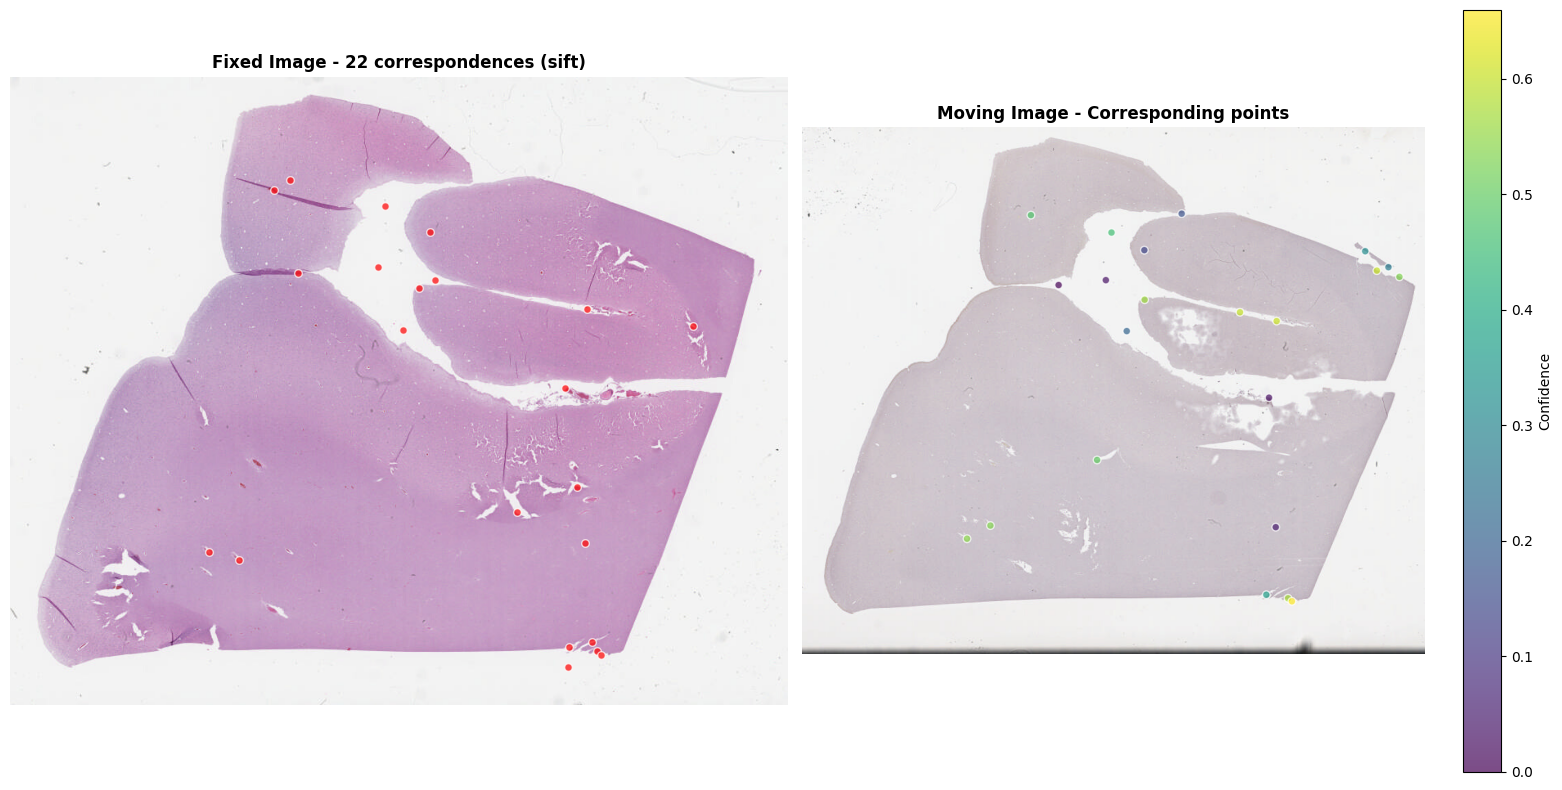

Correspondence method: sift
Total matches: 22
Average confidence: 0.373

Performing registration with 22 correspondences...

Visualizing registration results...


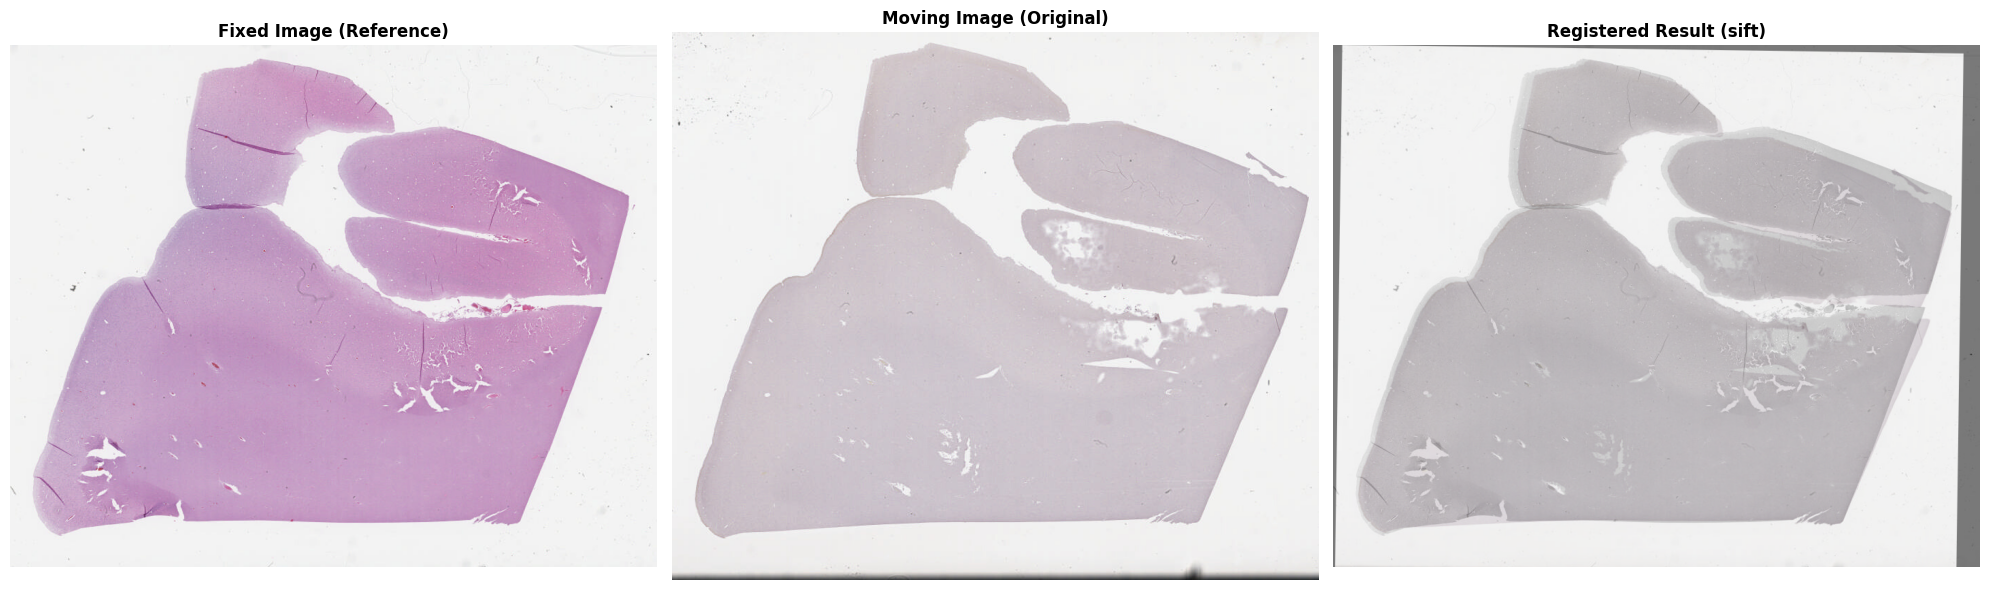


REGISTRATION METRICS
Method: sift
Matches: 22
Inliers: 5
Rotation: 0.80°
Scale: 1.0080
Translation: (13.70, 1.29) px
Dice Coefficient: 0.5832
NCC: 0.1196
SSIM: 0.7464
TPS Applied: False


In [53]:
# Example: Modular Registration with Different Correspondence Methods
# This cell will be executed after images are loaded (see cells below)

# Step 1: Choose correspondence method
CORRESPONDENCE_METHOD = "sift"  # Options: "lightglue", "sift", "orb", "akaze"

# Step 2: Generate correspondences (this is the modular middle function!)
print(f"Generating correspondences using: {CORRESPONDENCE_METHOD}")
correspondences = generate_correspondences(
    fixed_img,  # img1 - fixed/reference image
    moving_img,  # img2 - moving image
    method=CORRESPONDENCE_METHOD,
    # Method-specific parameters:
    extractor_type="superpoint" if CORRESPONDENCE_METHOD == "lightglue" else None,
    max_keypoints=2048 if CORRESPONDENCE_METHOD == "lightglue" else None,
    nfeatures=2000 if CORRESPONDENCE_METHOD in ["sift", "orb"] else None,
)

print(f"✓ Found {correspondences['num_matches']} correspondences using {correspondences['method']}")

# Step 3: Visualize correspondences (optional)
print("\nVisualizing correspondences...")
visualize_correspondences(fixed_img, moving_img, correspondences, max_points=100)

# Step 4: Perform registration using correspondences
print(f"\nPerforming registration with {correspondences['num_matches']} correspondences...")
registration_result = register_with_correspondences(
    correspondences,
    fixed_img,
    moving_img,
    affine_ransac_thresh=3.0,
    affine_max_iters=5000,
    tps_min_inliers=30,
    tps_smoothing=1.0
)

# Step 5: Visualize registration results
if registration_result['success']:
    print("\nVisualizing registration results...")
    visualize_registration_results(fixed_img, moving_img, registration_result)
else:
    print(f"\nRegistration failed: {registration_result.get('error', 'Unknown error')}")


## Compare Different Correspondence Methods

This section loops through multiple correspondence methods, generates correspondences for each, performs registration/warping, and compares the results.


COMPARING REGISTRATION METHODS
Includes both correspondence-based and intensity-based methods
Testing 5 methods...


Method: LightGlue (SuperPoint) (Correspondence-based)
  [1/3] Generating correspondences using lightglue...
         ✓ Found 511 correspondences
  [2/3] Performing registration with 511 correspondences...
         ✓ Registration successful
         - Matches: 511
         - Inliers: 143
         - Dice: 0.5937
         - SSIM: 0.7622
         - NCC: 0.1911
         - TPS Applied: True

Method: SIFT (Correspondence-based)
  [1/3] Generating correspondences using sift...
         ✓ Found 22 correspondences
  [2/3] Performing registration with 22 correspondences...
         ✓ Registration successful
         - Matches: 22
         - Inliers: 5
         - Dice: 0.5832
         - SSIM: 0.7464
         - NCC: 0.1196
         - TPS Applied: False

Method: ORB (Correspondence-based)
  [1/3] Generating correspondences using orb...
         ✓ Found 352 correspondences
  [2/3] Perf

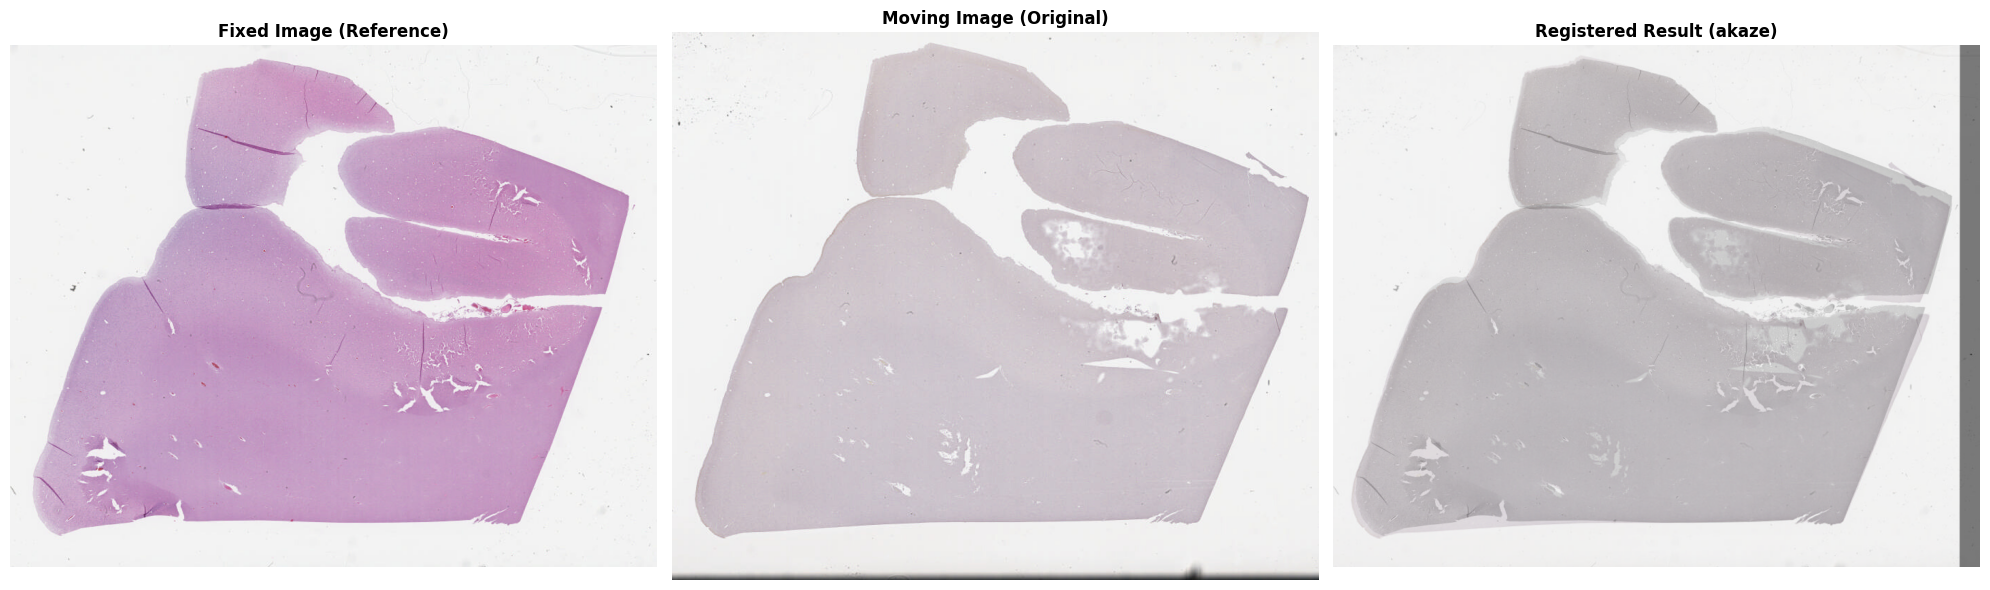


REGISTRATION METRICS
Method: akaze
Matches: 28
Inliers: 7
Rotation: 0.03°
Scale: 1.0234
Translation: (-5.78, -0.14) px
Dice Coefficient: 0.6005
NCC: 0.2547
SSIM: 0.7709
TPS Applied: False

Visualizing correspondences for best method (AKAZE)...


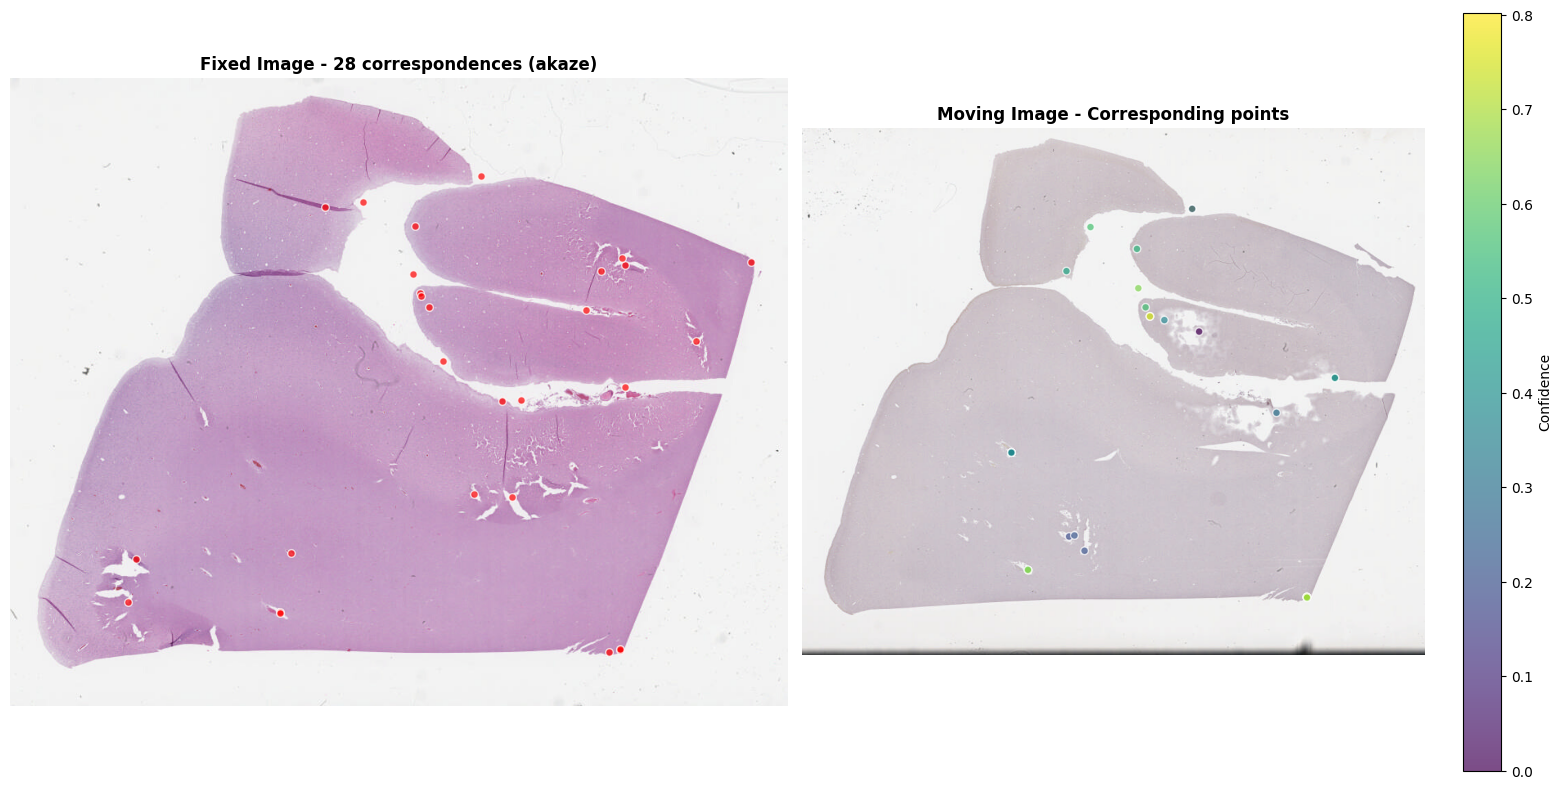

Correspondence method: akaze
Total matches: 28
Average confidence: 0.446


In [54]:
# Compare different correspondence methods
# This demonstrates the modular approach: loop through methods, generate correspondences, then register

# Define methods to compare (as a list or dictionary with parameters)
# Note: SimpleITK is different - it doesn't use correspondences, it's intensity-based
methods_to_compare = [
    {
        "method": "lightglue",
        "name": "LightGlue (SuperPoint)",
        "params": {
            "extractor_type": "superpoint",
            "max_keypoints": 2048
        },
        "type": "correspondence"  # Uses correspondences
    },
    {
        "method": "sift",
        "name": "SIFT",
        "params": {
            "nfeatures": 2000,
            "ratio_thresh": 0.75,
            "cross_check": True
        },
        "type": "correspondence"
    },
    {
        "method": "orb",
        "name": "ORB",
        "params": {
            "nfeatures": 2000
        },
        "type": "correspondence"
    },
    {
        "method": "akaze",
        "name": "AKAZE",
        "params": {
            "threshold": 0.001
        },
        "type": "correspondence"
    },
    {
        "method": "simpleitk",
        "name": "SimpleITK (Rigid)",
        "params": {
            "transform_type": "rigid"
        },
        "type": "intensity"  # Intensity-based, no correspondences
    },
    # Uncomment to also test SimpleITK with affine transform
    # {
    #     "method": "simpleitk",
    #     "name": "SimpleITK (Affine)",
    #     "params": {
    #         "transform_type": "affine"
    #     },
    #     "type": "intensity"
    # }
]

# Alternatively, use a simple list (will use default parameters)
# methods_to_compare = ["lightglue", "sift", "orb", "simpleitk"]

print("="*70)
print("COMPARING REGISTRATION METHODS")
print("="*70)
print("Includes both correspondence-based and intensity-based methods")
print(f"Testing {len(methods_to_compare)} methods...\n")

# Storage for results
results = {}

# Loop through each method
for method_config in methods_to_compare:
    # Handle both dict and string formats
    if isinstance(method_config, dict):
        method_name = method_config["name"]
        method = method_config["method"]
        params = method_config.get("params", {})
        method_type = method_config.get("type", "correspondence")  # Default to correspondence
    else:
        method_name = method_config.upper()
        method = method_config
        params = {}
        method_type = "correspondence" if method != "simpleitk" else "intensity"
    
    print(f"\n{'='*70}")
    print(f"Method: {method_name} ({'Intensity-based' if method_type == 'intensity' else 'Correspondence-based'})")
    print(f"{'='*70}")
    
    try:
        if method_type == "intensity":
            # SimpleITK: Direct registration (no correspondences)
            print(f"  [1/2] Performing intensity-based registration using {method}...")
            registration_result = register_with_simpleitk(
                fixed_img,
                moving_img,
                transform_type=params.get("transform_type", "rigid")
            )
            
            if registration_result['success']:
                num_matches = 0  # SimpleITK doesn't use correspondences
                num_inliers = 0
            else:
                results[method_name] = {
                    "success": False,
                    "error": registration_result.get('error', 'Unknown error')
                }
                continue
        else:
            # Correspondence-based methods: Generate correspondences first
            print(f"  [1/3] Generating correspondences using {method}...")
            correspondences = generate_correspondences(
                fixed_img, 
                moving_img,
                method=method,
                **params
            )
            
            num_matches = correspondences['num_matches']
            print(f"         ✓ Found {num_matches} correspondences")
            
            if num_matches < 4:
                print(f"         ✗ Insufficient matches for registration (need at least 4)")
                results[method_name] = {
                    "success": False,
                    "error": f"Insufficient matches: {num_matches}",
                    "correspondences": correspondences
                }
                continue
            
            # Step 2: Perform registration/warping
            print(f"  [2/3] Performing registration with {num_matches} correspondences...")
            registration_result = register_with_correspondences(
                correspondences,
                fixed_img,
                moving_img,
                affine_ransac_thresh=3.0,
                affine_max_iters=5000,
                tps_min_inliers=30,
                tps_smoothing=1.0
            )
            num_inliers = registration_result.get('num_inliers', 0) if registration_result.get('success') else 0
        
        if registration_result['success']:
            dice = registration_result.get('dice_coefficient', 0)
            ssim = registration_result.get('structural_similarity', 0)
            ncc = registration_result.get('normalized_cross_correlation', 0)
            tps_applied = registration_result.get('tps_applied', False)
            
            print(f"         ✓ Registration successful")
            if method_type == "correspondence":
                print(f"         - Matches: {num_matches}")
                print(f"         - Inliers: {num_inliers}")
            print(f"         - Dice: {dice:.4f}")
            print(f"         - SSIM: {ssim:.4f}")
            print(f"         - NCC: {ncc:.4f}")
            if method_type == "correspondence":
                print(f"         - TPS Applied: {tps_applied}")
            
            result_dict = {
                "success": True,
                "registration": registration_result,
                "num_matches": num_matches,
                "num_inliers": num_inliers,
                "dice": dice,
                "ssim": ssim,
                "ncc": ncc,
                "method_type": method_type
            }
            
            if method_type == "correspondence":
                result_dict["correspondences"] = correspondences
                result_dict["tps_applied"] = tps_applied
            
            results[method_name] = result_dict
        else:
            error_msg = registration_result.get('error', 'Unknown error')
            print(f"         ✗ Registration failed: {error_msg}")
            result_dict = {
                "success": False,
                "error": error_msg
            }
            if method_type == "correspondence":
                result_dict["correspondences"] = correspondences
                result_dict["num_matches"] = num_matches
            results[method_name] = result_dict
            
    except Exception as e:
        print(f"         ✗ Error: {str(e)}")
        results[method_name] = {
            "success": False,
            "error": str(e)
        }

# Step 3: Display comparison summary
print(f"\n{'='*70}")
print("COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"{'Method':<30} {'Type':<15} {'Matches':<10} {'Inliers':<10} {'Dice':<8} {'SSIM':<8} {'NCC':<8} {'TPS':<6}")
print("-"*110)

for method_name, result in results.items():
    if result.get('success', False):
        method_type = result.get('method_type', 'unknown')
        matches = result.get('num_matches', 0)
        inliers = result.get('num_inliers', 0)
        tps_info = 'Yes' if result.get('tps_applied', False) else 'No'
        if method_type == 'intensity':
            tps_info = 'N/A'  # SimpleITK doesn't use TPS
        
        print(f"{method_name:<30} {method_type:<15} {matches:<10} {inliers:<10} "
              f"{result['dice']:<8.4f} {result['ssim']:<8.4f} {result['ncc']:<8.4f} {tps_info:<6}")
    else:
        error = result.get('error', 'Unknown')
        matches = result.get('num_matches', 0)
        method_type = result.get('method_type', 'unknown')
        print(f"{method_name:<30} {method_type:<15} {matches:<10} {'FAILED':<10} {'-':<8} {'-':<8} {'-':<8} {'-':<6}")
        print(f"  Error: {error}")

print(f"{'='*70}")

# Step 4: Visualize best result (by Dice coefficient)
successful_results = {k: v for k, v in results.items() if v.get('success', False)}

if successful_results:
    # Find best method by Dice coefficient
    best_method = max(successful_results.items(), key=lambda x: x[1]['dice'])
    best_name, best_result = best_method
    
    print(f"\n{'='*70}")
    print(f"BEST METHOD: {best_name}")
    print(f"{'='*70}")
    method_type = best_result.get('method_type', 'unknown')
    print(f"Type: {method_type}")
    print(f"Dice Coefficient: {best_result['dice']:.4f}")
    print(f"SSIM: {best_result['ssim']:.4f}")
    print(f"NCC: {best_result['ncc']:.4f}")
    if method_type == 'correspondence':
        print(f"Matches: {best_result['num_matches']}")
        print(f"Inliers: {best_result['num_inliers']}")
        print(f"TPS Applied: {best_result.get('tps_applied', False)}")
    else:
        reg = best_result['registration']
        print(f"Transform Type: {reg.get('transform_type', 'rigid')}")
    
    print(f"\nVisualizing best result ({best_name})...")
    visualize_registration_results(
        fixed_img, 
        moving_img, 
        best_result['registration']
    )
    
    # Optional: Visualize correspondences for best method
    print(f"\nVisualizing correspondences for best method ({best_name})...")
    visualize_correspondences(
        fixed_img,
        moving_img,
        best_result['correspondences'],
        max_points=100
    )
else:
    print("\n⚠ No successful registrations to compare.")


## Optional: Visualize All Results Side-by-Side

Compare registration results from all methods visually.


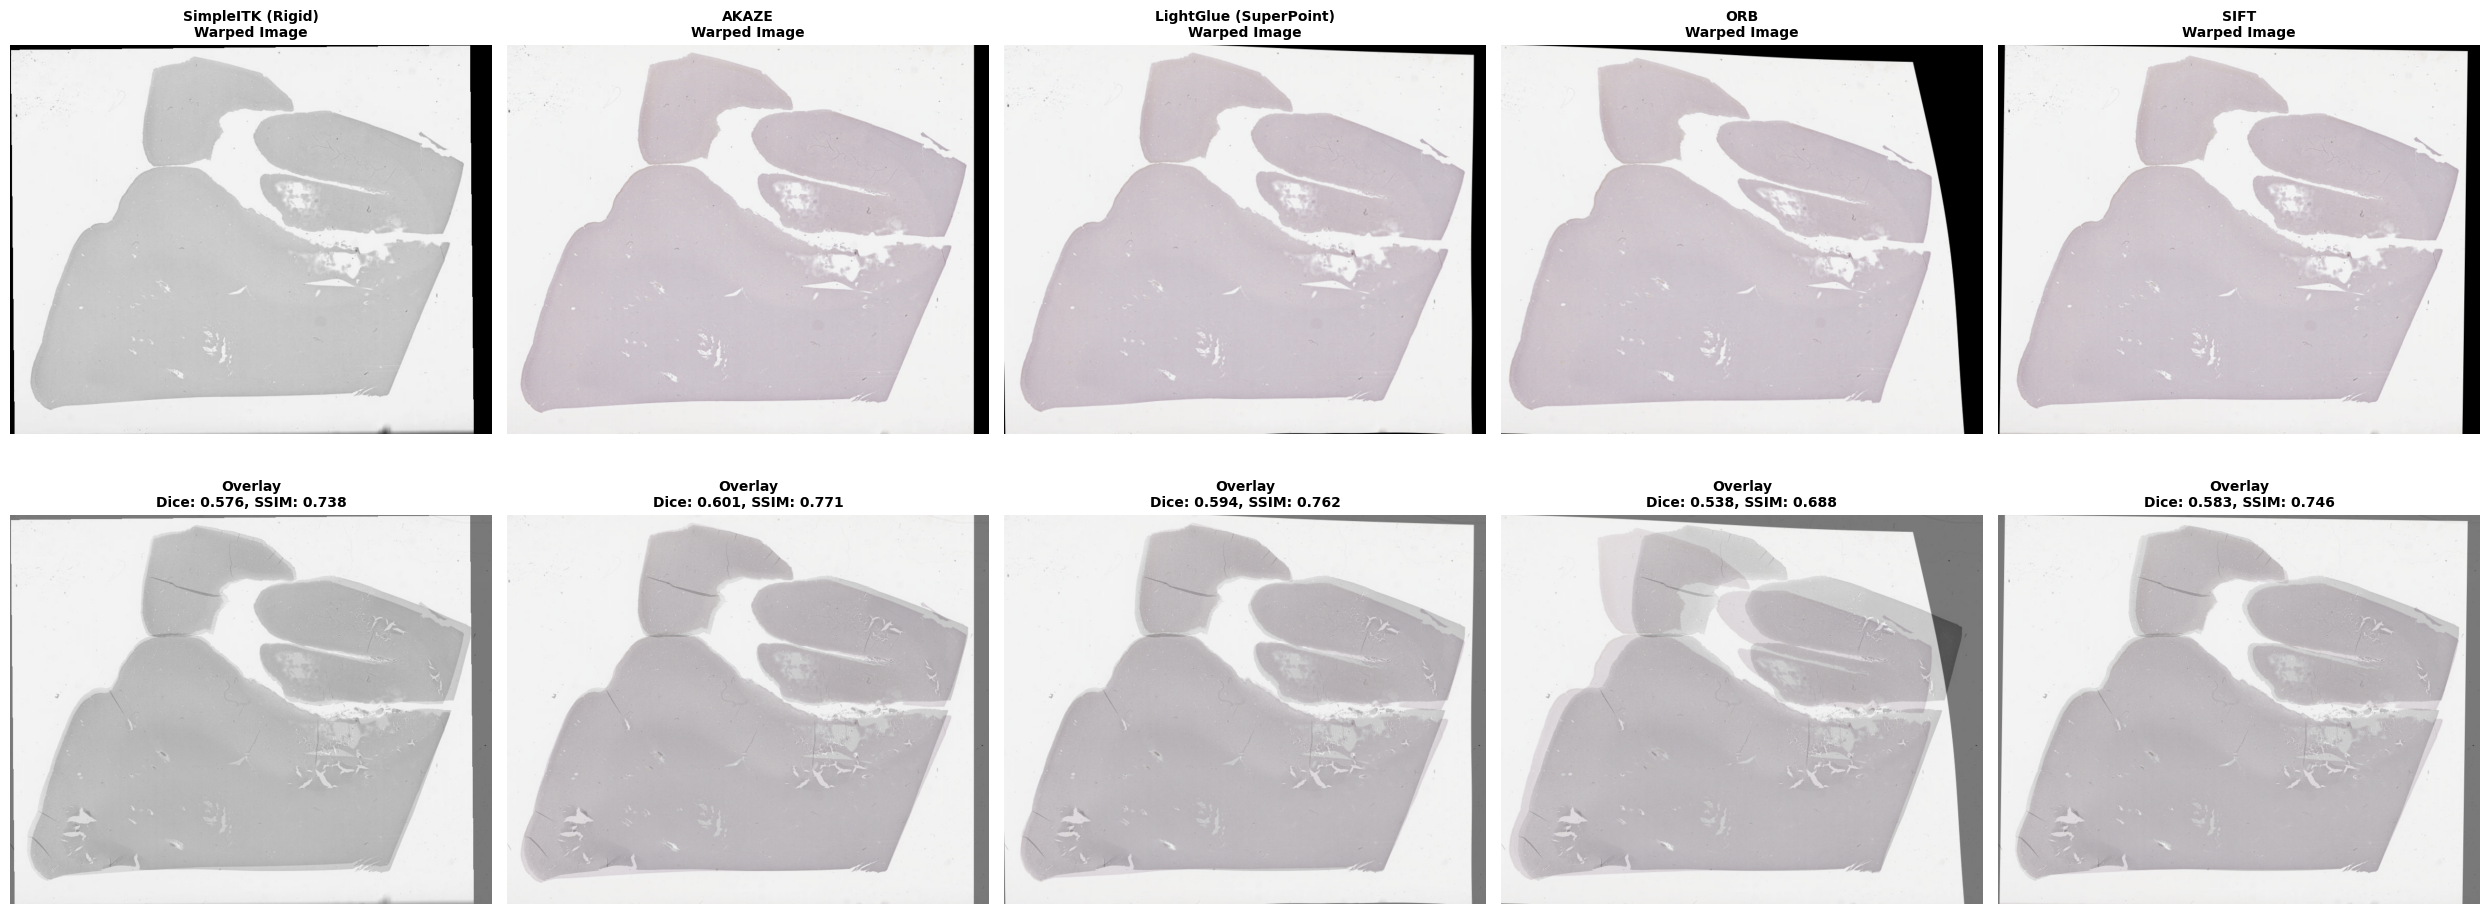


DETAILED METRICS FOR ALL METHODS

SimpleITK (Rigid) (intensity):
  Type: Intensity-based (no correspondences)
  Transform Type: rigid
  Dice Coefficient: 0.5756
  SSIM: 0.7378
  NCC: 0.0795
  Rotation: 0.57°
  Scale: 1.0000
  Translation: (-5.35, -7.00) px

AKAZE (correspondence):
  Matches: 28
  Inliers: 7
  TPS Applied: False
  Dice Coefficient: 0.6005
  SSIM: 0.7709
  NCC: 0.2547
  Rotation: 0.03°
  Scale: 1.0234
  Translation: (-5.78, -0.14) px

LightGlue (SuperPoint) (correspondence):
  Matches: 511
  Inliers: 143
  TPS Applied: True
  Dice Coefficient: 0.5937
  SSIM: 0.7622
  NCC: 0.1911
  Rotation: 0.44°
  Scale: 1.0172
  Translation: (3.07, -2.23) px

ORB (correspondence):
  Matches: 352
  Inliers: 30
  TPS Applied: True
  Dice Coefficient: 0.5376
  SSIM: 0.6885
  NCC: -0.1170
  Rotation: 0.34°
  Scale: 1.0128
  Translation: (5.97, 2.60) px

SIFT (correspondence):
  Matches: 22
  Inliers: 5
  TPS Applied: False
  Dice Coefficient: 0.5832
  SSIM: 0.7464
  NCC: 0.1196
  Rotation

In [55]:
# Optional: Visualize all successful registration results side-by-side

successful_results = {k: v for k, v in results.items() if v.get('success', False)}

if len(successful_results) > 0:
    # Sort results: SimpleITK first, then others
    sorted_results = sorted(
        successful_results.items(),
        key=lambda x: (0 if 'simpleitk' in x[0].lower() else 1, x[0])
    )
    
    num_methods = len(sorted_results)
    fig, axes = plt.subplots(2, num_methods, figsize=(5*num_methods, 10))
    
    if num_methods == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (method_name, result) in enumerate(sorted_results):
        warped_img = result['registration'].get('warped_image')
        if warped_img is None:
            continue
        
        # Convert BGR to RGB if needed
        if len(warped_img.shape) == 3:
            warped_rgb = cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB)
        else:
            warped_rgb = warped_img
        
        # Create overlay
        fixed_gray = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2GRAY) if len(fixed_img.shape) == 3 else fixed_img
        fixed_gray_3ch = cv2.cvtColor(fixed_gray, cv2.COLOR_GRAY2RGB) if len(fixed_gray.shape) == 2 else fixed_img
        overlay = (fixed_gray_3ch * 0.5 + warped_rgb * 0.5).astype(np.uint8)
        
        # Top row: Warped images
        axes[0, idx].imshow(warped_rgb)
        axes[0, idx].set_title(f'{method_name}\nWarped Image', fontsize=10, fontweight='bold')
        axes[0, idx].axis('off')
        
        # Bottom row: Overlays
        axes[1, idx].imshow(overlay)
        title = f'Overlay\nDice: {result["dice"]:.3f}, SSIM: {result["ssim"]:.3f}'
        axes[1, idx].set_title(title, fontsize=10, fontweight='bold')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics for all methods (using same sorted order)
    print("\n" + "="*70)
    print("DETAILED METRICS FOR ALL METHODS")
    print("="*70)
    for method_name, result in sorted_results:
        method_type = result.get('method_type', 'unknown')
        print(f"\n{method_name} ({method_type}):")
        if method_type == 'correspondence':
            print(f"  Matches: {result['num_matches']}")
            print(f"  Inliers: {result['num_inliers']}")
            print(f"  TPS Applied: {result.get('tps_applied', False)}")
        else:
            print(f"  Type: Intensity-based (no correspondences)")
            reg = result['registration']
            print(f"  Transform Type: {reg.get('transform_type', 'rigid')}")
        print(f"  Dice Coefficient: {result['dice']:.4f}")
        print(f"  SSIM: {result['ssim']:.4f}")
        print(f"  NCC: {result['ncc']:.4f}")
        reg = result['registration']
        print(f"  Rotation: {reg.get('rotation_degrees', 0):.2f}°")
        print(f"  Scale: {reg.get('scale', 1):.4f}")
        print(f"  Translation: ({reg.get('offset_x', 0):.2f}, {reg.get('offset_y', 0):.2f}) px")
else:
    print("No successful results to visualize.")
